# Fresh Orange vs Formalin-mixed Orange — Kaggle

## Setup

In [2]:
import os
import shutil
import random
import zipfile
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# No Kaggle API credentials needed here: the dataset is attached to this
# notebook as an Input (read-only, already mounted under /kaggle/input),
# so there is nothing to download.

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f'TensorFlow version: {tf.__version__}')


TensorFlow version: 2.20.0


In [3]:
results_dir = "/kaggle/working/results/"
models_dir = "/kaggle/working/models/"
os.makedirs(results_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)


In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPUs available: {len(gpus)}')
    for gpu in gpus:
        print(f' - {gpu}')
        # Let TF grow GPU memory as needed instead of grabbing it all up
        # front -- avoids a common class of GPU-OOM crash on shared Kaggle GPUs.
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(f'   (memory growth not set: {e})')
else:
    print('No GPU found. On Kaggle: Settings (right panel) > Accelerator > GPU T4 x2 / P100.')

# Mixed precision: MobileNetV2 + a small classification head is well within
# a T4/P100's memory budget, so this is purely a speed win (roughly 1.5-2x
# faster on Tensor Core GPUs) with negligible accuracy impact, as long as
# the final layer stays float32 for numerically-stable loss computation
# (handled explicitly in build_transfer_model below).
USE_MIXED_PRECISION = True
if USE_MIXED_PRECISION and gpus:
    try:
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision enabled (mixed_float16).')
    except Exception as e:
        print(f'Mixed precision not enabled: {e}')


No GPU found. On Kaggle: Settings (right panel) > Accelerator > GPU T4 x2 / P100.


2026-07-29 07:44:16.546838: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Locate dataset (already mounted on Kaggle)

In [5]:
def find_dataset_root():
    """Locate the FruitVision dataset under /kaggle/input without assuming
    an exact folder name (the mounted folder name can differ slightly from
    account to account). Prints what it finds so you can sanity-check it."""
    root = Path('/kaggle/input')
    if not root.exists():
        raise FileNotFoundError(
            "No /kaggle/input found. Attach the "
            "'fresh-rotten-and-formalin-mixed-fruit-detection' dataset to this "
            "notebook first (Add Input, right-hand panel)."
        )
    attached = sorted(p.name for p in root.iterdir())
    print(f'Datasets attached to this notebook: {attached}')
    if not attached:
        raise FileNotFoundError('No datasets attached under /kaggle/input.')

    fruit_like = [d for d in attached if any(k in d.lower() for k in ('fruit', 'formalin', 'orange'))]
    chosen = fruit_like[0] if fruit_like else attached[0]
    cur = root / chosen
    print(f'Using attached dataset: {cur}')

    # Kaggle sometimes nests the real content one level deeper, inside a
    # folder that repeats the dataset title. Descend through any such
    # single-subfolder wrappers until we hit the real content.
    for _ in range(4):
        entries = list(cur.iterdir())
        subdirs = [e for e in entries if e.is_dir()]
        files = [e for e in entries if e.is_file()]
        if len(subdirs) == 1 and not files:
            cur = subdirs[0]
        else:
            break
    return cur

DATASET_ROOT = find_dataset_root()
print(f'DATASET_ROOT = {DATASET_ROOT}')
print(f'Contents: {sorted(p.name for p in DATASET_ROOT.iterdir())}')


Datasets attached to this notebook: ['datasets', 'notebooks']
Using attached dataset: /kaggle/input/datasets
DATASET_ROOT = /kaggle/input/datasets/sumitkumerdas/fresh-rotten-and-formalin-mixed-fruit-detection/Fruits Original-ML-GRP-07
Contents: ['Apple', 'Banana', 'Grape', 'Mango', 'Orange', 'desktop.ini']


In [6]:
WORK_DATASET_DIR = Path('/kaggle/working/fruitvision_extracted')

def ensure_extracted(dataset_root: Path) -> Path:
    """FruitVision sometimes ships its two main folders as nested zip files
    ('Original Image.zip', 'Augmented-Resized Image.zip'). /kaggle/input is
    read-only, so any such inner zips must be extracted into /kaggle/working
    instead of in place. If there's nothing to extract, use the mounted
    (read-only) folder directly -- no unnecessary copying."""
    zip_files = list(dataset_root.rglob('*.zip'))
    if not zip_files:
        return dataset_root

    WORK_DATASET_DIR.mkdir(parents=True, exist_ok=True)
    for z in zip_files:
        marker = WORK_DATASET_DIR / (z.stem + '.done')
        out_dir = WORK_DATASET_DIR / z.stem
        if marker.exists():
            print(f'Already extracted: {z.name}')
            continue
        print(f'Extracting {z.name} ...')
        with zipfile.ZipFile(z, 'r') as zf:
            zf.extractall(out_dir)
        marker.touch()
    return WORK_DATASET_DIR

DATASET_DIR = ensure_extracted(DATASET_ROOT)
print(f'DATASET_DIR = {DATASET_DIR}')


DATASET_DIR = /kaggle/input/datasets/sumitkumerdas/fresh-rotten-and-formalin-mixed-fruit-detection/Fruits Original-ML-GRP-07


## Curate Fresh vs Formalin-mixed Orange classes

In [7]:
# Efficiency + data-leakage note:
# FruitVision ships two parallel copies of its data: "Original Image"
# (~10k base photos) and "Augmented-Resized Image" (the same photos
# multiplied ~8x via rotation/zoom/brightness). Using both and then doing a
# *random* 70/15/15 split would let augmented near-duplicates of a training
# photo leak into validation/test -- inflating scores -- and would also
# multiply training time roughly 8x for no real benefit. We curate from
# "Original Image" only by default: it's already plenty of data for a
# 2-class task and keeps the split honest and training fast.
USE_AUGMENTED_DATA = False  # True: add the augmented copies into TRAIN only (never val/test)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}
CLASS_KEYWORDS = {'fresh': ['fresh'], 'formalin': ['formalin']}

def matches_class(path_obj, keywords):
    path_str = str(path_obj).lower()
    return 'orange' in path_str and any(kw in path_str for kw in keywords)

def collect_class_files(root_dir):
    leaf_folders = []
    for dirpath, dirnames, filenames in os.walk(root_dir):
        if any(Path(f).suffix in IMG_EXTS for f in filenames):
            leaf_folders.append(Path(dirpath))
    files = {'fresh': [], 'formalin': []}
    for folder in leaf_folders:
        for class_name, keywords in CLASS_KEYWORDS.items():
            if matches_class(folder, keywords):
                for img_path in folder.iterdir():
                    if img_path.suffix in IMG_EXTS:
                        files[class_name].append(img_path)
    return files

original_candidates = [p for p in DATASET_DIR.rglob('*') if p.is_dir() and 'original' in p.name.lower()]
SOURCE_DIR = original_candidates[0] if original_candidates else DATASET_DIR
print(f'Curating from: {SOURCE_DIR}')

all_files = collect_class_files(SOURCE_DIR)
print(f'Base (Original Image) -- Fresh: {len(all_files["fresh"])}, Formalin: {len(all_files["formalin"])}')

aug_files = {'fresh': [], 'formalin': []}
if USE_AUGMENTED_DATA:
    aug_candidates = [p for p in DATASET_DIR.rglob('*') if p.is_dir() and 'augmented' in p.name.lower()]
    if aug_candidates:
        aug_files = collect_class_files(aug_candidates[0])
        print(f'Augmented extra (train-only) -- Fresh: {len(aug_files["fresh"])}, Formalin: {len(aug_files["formalin"])}')
    else:
        print('USE_AUGMENTED_DATA=True but no "augmented" folder was found -- skipping.')

if not all_files['fresh'] and not all_files['formalin']:
    raise RuntimeError(
        'No fresh/formalin orange images found. Print DATASET_DIR\'s contents '
        '(e.g. list(DATASET_DIR.rglob("*"))[:30]) to check the actual folder names.'
    )


Curating from: /kaggle/input/datasets/sumitkumerdas/fresh-rotten-and-formalin-mixed-fruit-detection/Fruits Original-ML-GRP-07
Base (Original Image) -- Fresh: 2056, Formalin: 2056


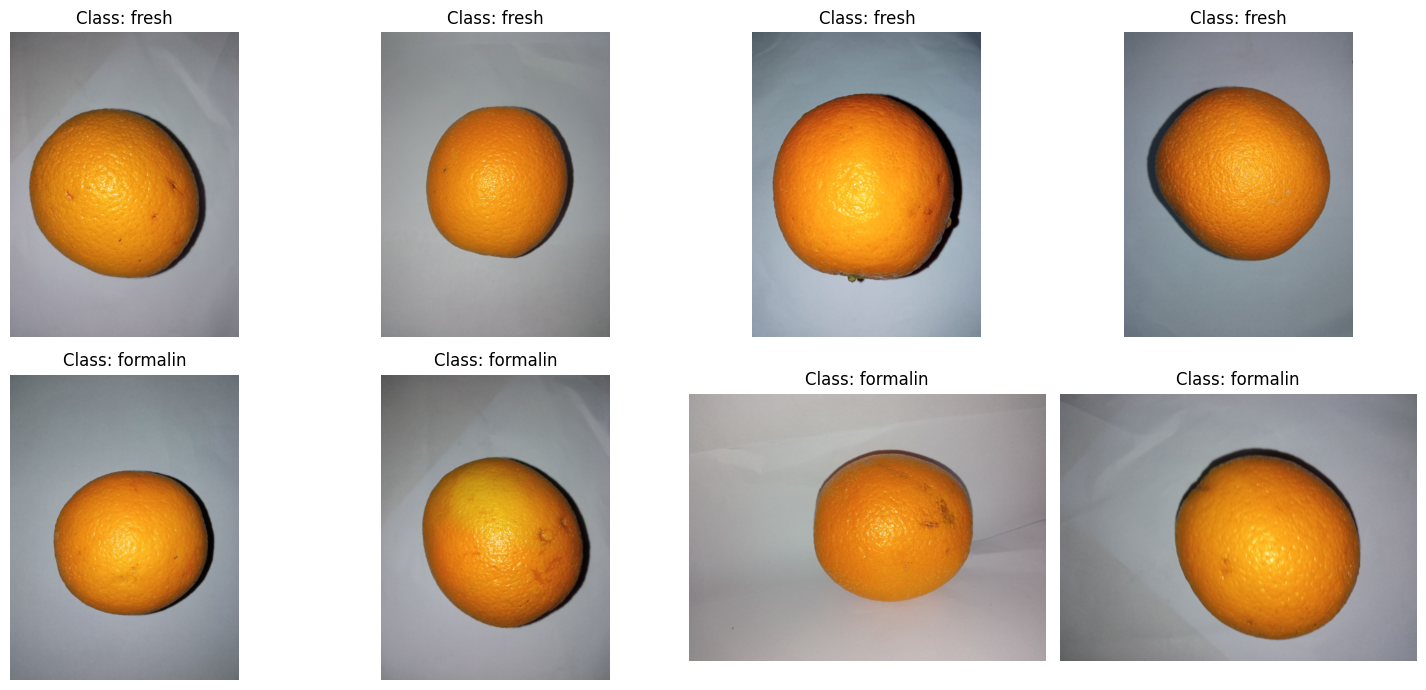

In [8]:
def visualize_curated_data(all_files, num_images=4):
    plt.figure(figsize=(15, 7))
    classes_to_show = ['fresh', 'formalin']
    for i, class_name in enumerate(classes_to_show):
        file_list = all_files.get(class_name, [])
        if not file_list:
            print(f"No images found for class: {class_name}")
            continue
        samples = random.sample(file_list, min(num_images, len(file_list)))
        for j, img_path in enumerate(samples):
            plt.subplot(len(classes_to_show), num_images, i * num_images + j + 1)
            img = mpimg.imread(str(img_path))
            plt.imshow(img)
            plt.title(f"Class: {class_name}")
            plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_curated_data(all_files)


## Split 70/15/15

In [9]:
random.seed(SEED)

CURATED_ROOT = Path('/kaggle/working/binary_dataset')
if CURATED_ROOT.exists():
    shutil.rmtree(CURATED_ROOT)

def link_or_copy(src, dst):
    """Symlink is near-instant and uses no extra disk (important with up to
    ~10k source images); fall back to a real copy only if the filesystem
    doesn't support symlinks."""
    try:
        os.symlink(os.path.abspath(src), dst)
    except OSError:
        shutil.copy(str(src), str(dst))

for class_name, files in all_files.items():
    files = list(files)
    random.shuffle(files)
    n = len(files)
    n_train = int(n * 0.70)
    n_val = int(n * 0.15)

    split_files = {
        'train': files[:n_train],
        'val': files[n_train:n_train + n_val],
        'test': files[n_train + n_val:],
    }
    # Extra augmented images (if enabled) go into TRAIN ONLY, so val/test
    # metrics stay an honest estimate on real, non-duplicated photos.
    split_files['train'] = split_files['train'] + aug_files.get(class_name, [])

    for split, split_file_list in split_files.items():
        dst_dir = CURATED_ROOT / split / class_name
        dst_dir.mkdir(parents=True, exist_ok=True)
        # Index-prefix filenames: source folders can repeat generic names
        # like IMG_0001.jpg, which would otherwise silently collide/overwrite.
        for idx, src_file in enumerate(split_file_list):
            dst_file = dst_dir / f'{idx:05d}_{src_file.name}'
            link_or_copy(src_file, dst_file)

for split in ['train', 'val', 'test']:
    for class_name in ['fresh', 'formalin']:
        d = CURATED_ROOT / split / class_name
        n = len(list(d.glob('*'))) if d.exists() else 0
        print(f'{split} / {class_name}: {n}')


train / fresh: 1439
train / formalin: 1439
val / fresh: 308
val / formalin: 308
test / fresh: 309
test / formalin: 309


## Hyperparameters

In [10]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH  = 224
BATCH_SIZE   = 32
EPOCHS       = 20
LR           = 1e-4


## Load datasets

In [11]:
for s in ['train', 'val', 'test']:
    path = CURATED_ROOT / s
    if path.exists():
        print(f"Content of {path}:", os.listdir(path))

train_dataset = tf.keras.utils.image_dataset_from_directory(
    str(CURATED_ROOT / 'train'),
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=SEED,
    shuffle=True,
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    str(CURATED_ROOT / 'val'),
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=SEED,
    shuffle=False,
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    str(CURATED_ROOT / 'test'),
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=SEED,
    shuffle=False,
)

class_names = train_dataset.class_names
print("Detected classes:", class_names)


Content of /kaggle/working/binary_dataset/train: ['formalin', 'fresh']
Content of /kaggle/working/binary_dataset/val: ['formalin', 'fresh']
Content of /kaggle/working/binary_dataset/test: ['formalin', 'fresh']
Found 2878 files belonging to 2 classes.
Found 616 files belonging to 2 classes.
Found 618 files belonging to 2 classes.
Detected classes: ['formalin', 'fresh']


## Pipeline

In [12]:
AUTOTUNE = tf.data.AUTOTUNE
CACHE_DIR = Path('/kaggle/working/tf_cache')
if CACHE_DIR.exists():
    shutil.rmtree(CACHE_DIR)  # avoid stale/corrupt cache files on re-runs
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Caching to disk (not bare .cache(), which would hold every decoded image
# in RAM) keeps memory bounded regardless of dataset size. The shuffle
# buffer is sized in BATCHES (20 batches = 640 images), not the whole
# dataset, so it stays cheap too.
train_dataset = (
    train_dataset.cache(str(CACHE_DIR / 'train'))
    .shuffle(20, seed=SEED)
    .prefetch(buffer_size=AUTOTUNE)
)
val_dataset = val_dataset.cache(str(CACHE_DIR / 'val')).prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache(str(CACHE_DIR / 'test')).prefetch(buffer_size=AUTOTUNE)
print('Data pipeline ready (train/val/test cached to disk, bounded shuffle buffer).')


Data pipeline ready (train/val/test cached to disk, bounded shuffle buffer).


In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name='data_augmentation')


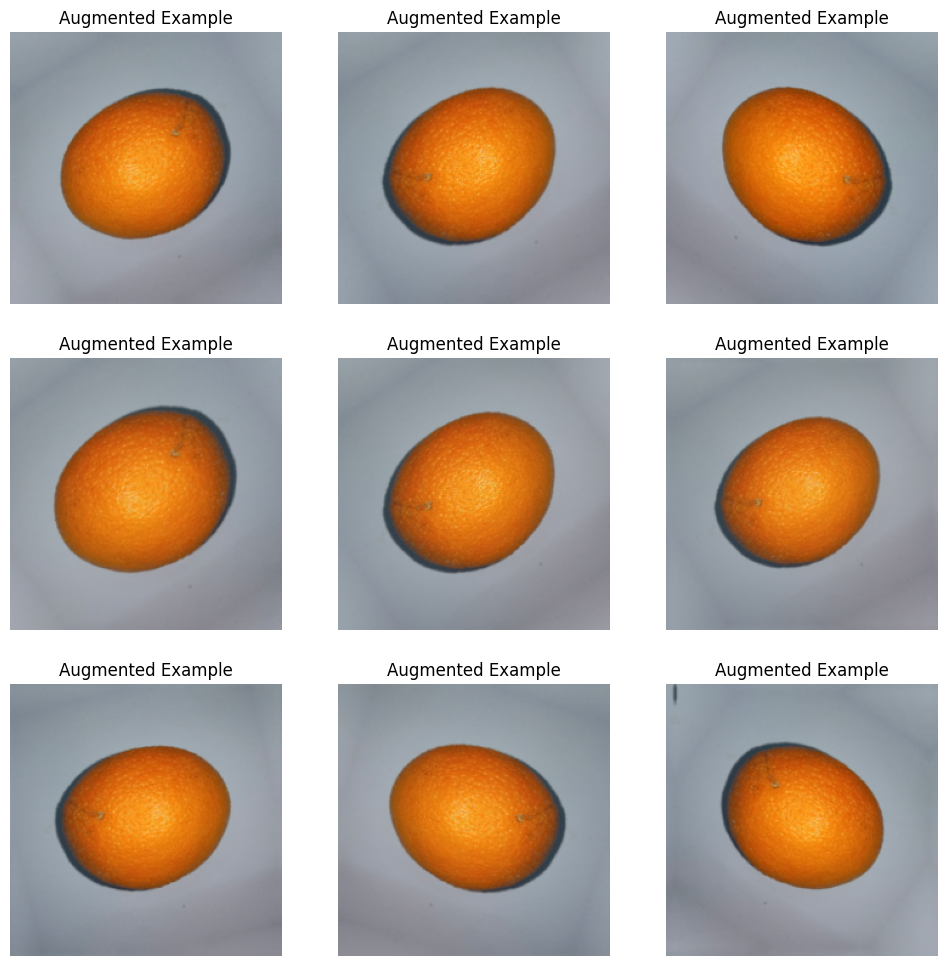

In [14]:
def show_augmentation_results(dataset, augmentation_layer):
    plt.figure(figsize=(12, 12))
    for images, _ in dataset.take(1):
        for i in range(9):
            augmented_images = augmentation_layer(images, training=True)
            plt.subplot(3, 3, i + 1)
            plt.imshow(augmented_images[0].numpy().astype("uint8"))
            plt.title("Augmented Example")
            plt.axis("off")
    plt.show()

show_augmentation_results(train_dataset, data_augmentation)


## Helper functions

In [15]:
def make_callbacks(name):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'{models_dir}{name}_best.keras',
            monitor='val_loss', mode='min', save_best_only=True, verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=6, restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1,
        ),
    ]


def plot_learning_curves(history, title='Learning Curves'):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy', linestyle='--')
    plt.legend(); plt.title(f'{title} - Accuracy'); plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss', linestyle='--')
    plt.legend(); plt.title(f'{title} - Loss'); plt.grid(alpha=0.3)

    plt.tight_layout()
    safe_title = title.lower().replace(' ', '_')
    plt.savefig(results_dir + f'{safe_title}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()


def evaluate_model(model, dataset, class_names, title='Model', plot=True):
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0).ravel()
        y_prob.append(probs)
        y_pred.append((probs >= 0.5).astype(int))
        y_true.append(labels.numpy().ravel().astype(int))

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    loss, acc, precision, recall, auc = model.evaluate(dataset, verbose=0)
    f1 = f1_score(y_true, y_pred)

    metrics = {
        'loss': loss, 'accuracy': acc, 'precision': precision,
        'recall': recall, 'f1': f1, 'auc': auc,
    }

    print(f'\n{title}')
    for k, v in metrics.items():
        print(f'{k:>10}: {v:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    if plot:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, cmap='Blues', cbar=False, annot=True, fmt='d',
                    xticklabels=class_names, yticklabels=class_names,
                    annot_kws={'fontsize': 11, 'fontweight': 'bold'})
        plt.title(f'{title} - Confusion Matrix')
        plt.xlabel('Predicted'); plt.ylabel('True')
        plt.tight_layout()
        safe_title = title.lower().replace(' ', '_')
        plt.savefig(results_dir + f'{safe_title}_confusion.png', dpi=120, bbox_inches='tight')
        plt.show()
        plt.close()

    return metrics


## Build model

In [16]:
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)

# NOTE: MobileNetV2 downloads ImageNet weights from the internet the first
# time it's built. On Kaggle, make sure Settings (right panel) > Internet
# is switched On, or this cell will fail.

def build_transfer_model(input_shape, augmentation):
    # Assignment requirement: MobileNetV2 -- already a lightweight,
    # efficient backbone (~3.5M params) well suited to a 2-class task.
    base_model = tf.keras.applications.MobileNetV2(
        weights='imagenet', input_shape=input_shape, include_top=False,
    )
    preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input
    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = preprocess_fn(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    # dtype='float32' keeps the sigmoid output (and its loss) numerically
    # stable even when mixed precision is enabled for the rest of the model.
    outputs = tf.keras.layers.Dense(1, activation='sigmoid', dtype='float32')(x)

    return tf.keras.Model(inputs, outputs, name='mobilenetv2_assignment'), base_model

tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation)
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)
tl_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenetv2_assignment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,916,417 (11.13 MB)

 Trainable params: 657,409 (2.51 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

## Train - feature extraction

In [17]:
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')],
)

tl_history = tl_model.fit(
    train_dataset, validation_data=val_dataset, epochs=EPOCHS,
    callbacks=make_callbacks('feature_extraction'), verbose=2,
)


Epoch 1/20

Epoch 1: val_loss improved from None to 0.71558, saving model to /kaggle/working/models/feature_extraction_best.keras

Epoch 1: finished saving model to /kaggle/working/models/feature_extraction_best.keras
90/90 - 69s - 770ms/step - accuracy: 0.4896 - auc: 0.4881 - loss: 0.9417 - precision: 0.4893 - recall: 0.4774 - val_accuracy: 0.4805 - val_auc: 0.4814 - val_loss: 0.7156 - val_precision: 0.4864 - val_recall: 0.6981 - learning_rate: 1.0000e-04
Epoch 2/20

Epoch 2: val_loss did not improve from 0.71558
90/90 - 52s - 579ms/step - accuracy: 0.4889 - auc: 0.4942 - loss: 0.8828 - precision: 0.4888 - recall: 0.4858 - val_accuracy: 0.4562 - val_auc: 0.4743 - val_loss: 0.7233 - val_precision: 0.4702 - val_recall: 0.6916 - learning_rate: 1.0000e-04
Epoch 3/20

Epoch 3: val_loss did not improve from 0.71558
90/90 - 52s - 581ms/step - accuracy: 0.4885 - auc: 0.4905 - loss: 0.8733 - precision: 0.4885 - recall: 0.4864 - val_accuracy: 0.4513 - val_auc: 0.4612 - val_loss: 0.7432 - val_pr

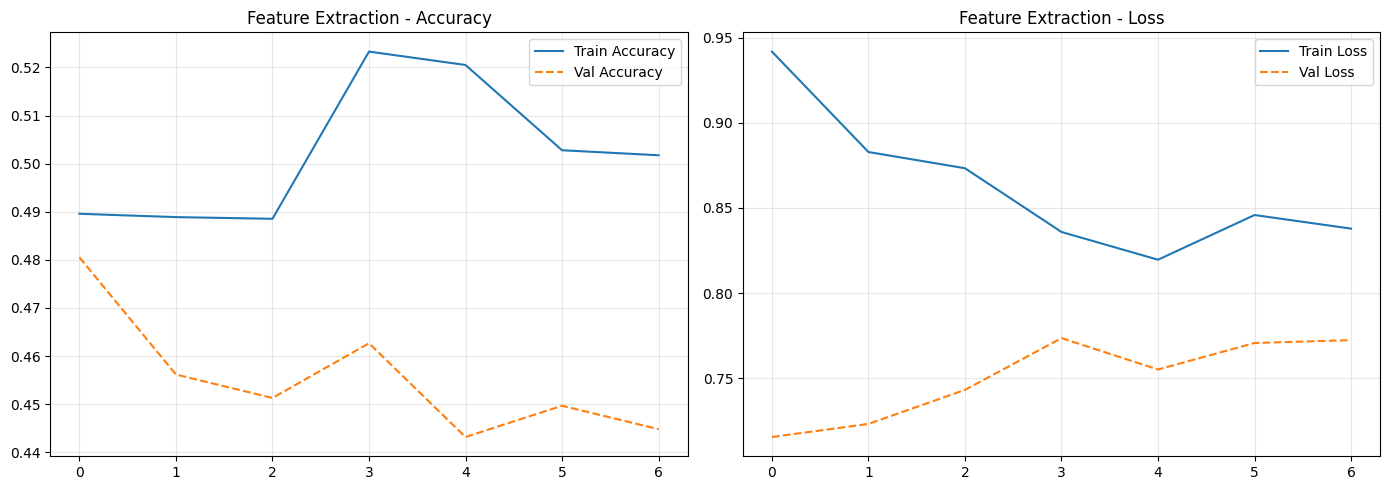

2026-07-29 07:51:47.823827: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Feature Extraction (val)
      loss: 0.7156
  accuracy: 0.4805
 precision: 0.4864
    recall: 0.6981
        f1: 0.5733
       auc: 0.4814

              precision    recall  f1-score   support

    formalin     0.4655    0.2630    0.3361       308
       fresh     0.4864    0.6981    0.5733       308

    accuracy                         0.4805       616
   macro avg     0.4760    0.4805    0.4547       616
weighted avg     0.4760    0.4805    0.4547       616



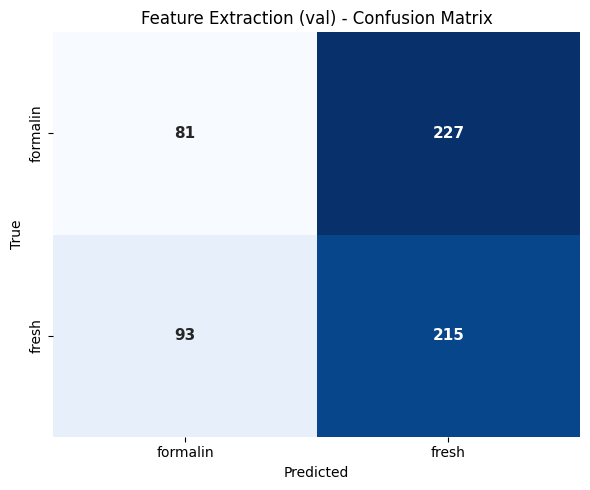

In [18]:
plot_learning_curves(tl_history, 'Feature Extraction')
fe_val_metrics = evaluate_model(tl_model, val_dataset, class_names, 'Feature Extraction (val)')


## Fine-tune

In [19]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

FINETUNE_LR = LR / 10

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')],
)

ft_history = tl_model.fit(
    train_dataset, validation_data=val_dataset, epochs=10,
    callbacks=make_callbacks('finetuned'), verbose=2,
)


Epoch 1/10

Epoch 1: val_loss improved from None to 0.72521, saving model to /kaggle/working/models/finetuned_best.keras

Epoch 1: finished saving model to /kaggle/working/models/finetuned_best.keras
90/90 - 72s - 801ms/step - accuracy: 0.5003 - auc: 0.5009 - loss: 0.9713 - precision: 0.5003 - recall: 0.5024 - val_accuracy: 0.4756 - val_auc: 0.4862 - val_loss: 0.7252 - val_precision: 0.4809 - val_recall: 0.6136 - learning_rate: 1.0000e-05
Epoch 2/10

Epoch 2: val_loss did not improve from 0.72521
90/90 - 64s - 710ms/step - accuracy: 0.5097 - auc: 0.5216 - loss: 0.9188 - precision: 0.5094 - recall: 0.5261 - val_accuracy: 0.5000 - val_auc: 0.4824 - val_loss: 0.7383 - val_precision: 0.5000 - val_recall: 0.4383 - learning_rate: 1.0000e-05
Epoch 3/10

Epoch 3: val_loss did not improve from 0.72521
90/90 - 63s - 703ms/step - accuracy: 0.5038 - auc: 0.5200 - loss: 0.9220 - precision: 0.5037 - recall: 0.5163 - val_accuracy: 0.4886 - val_auc: 0.4696 - val_loss: 0.7704 - val_precision: 0.4819 - 

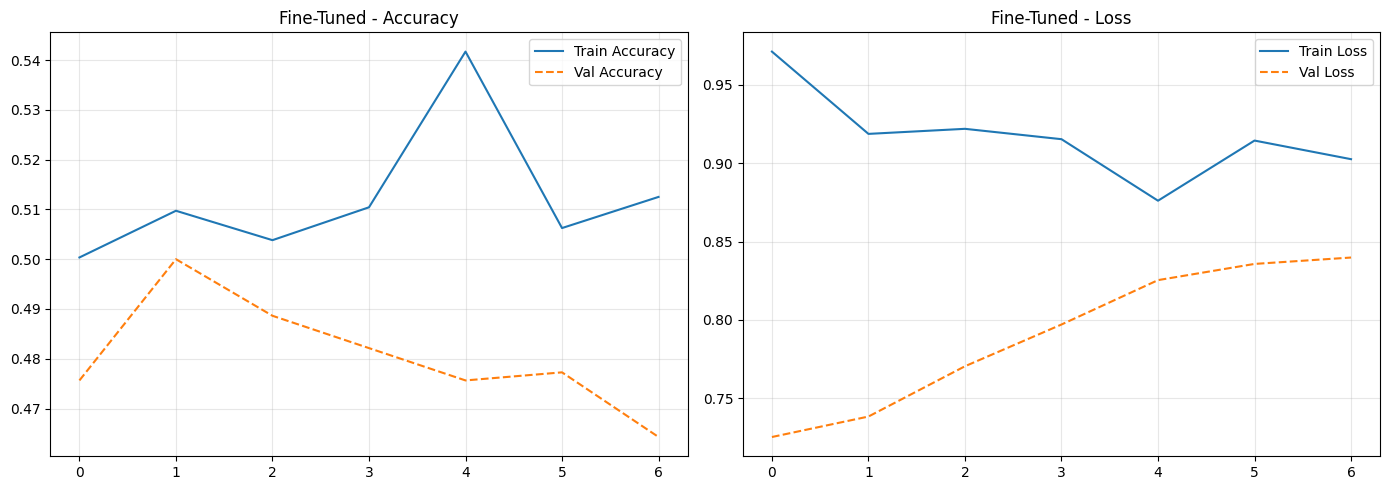

2026-07-29 07:59:41.290674: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Fine-Tuned (val)
      loss: 0.7252
  accuracy: 0.4756
 precision: 0.4809
    recall: 0.6136
        f1: 0.5392
       auc: 0.4862

              precision    recall  f1-score   support

    formalin     0.4664    0.3377    0.3917       308
       fresh     0.4809    0.6136    0.5392       308

    accuracy                         0.4756       616
   macro avg     0.4736    0.4756    0.4655       616
weighted avg     0.4736    0.4756    0.4655       616



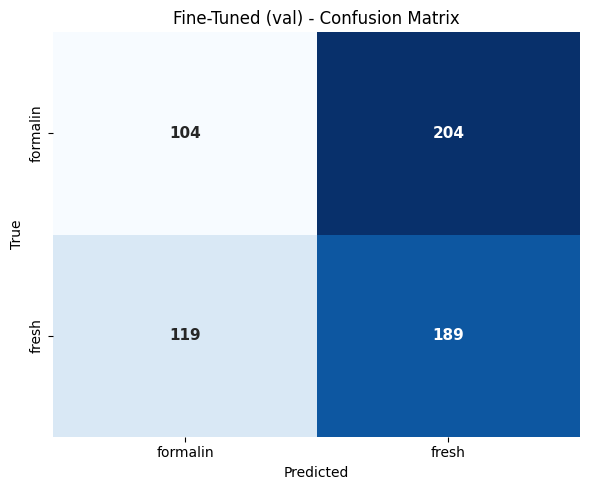

In [20]:
plot_learning_curves(ft_history, 'Fine-Tuned')
ft_val_metrics = evaluate_model(tl_model, val_dataset, class_names, 'Fine-Tuned (val)')


## Select best model

In [21]:
fe_model = tf.keras.models.load_model(f'{models_dir}feature_extraction_best.keras')
ft_model = tf.keras.models.load_model(f'{models_dir}finetuned_best.keras')

fe_metrics = evaluate_model(fe_model, val_dataset, class_names, 'Feature Extraction checkpoint (val)', plot=False)
ft_metrics = evaluate_model(ft_model, val_dataset, class_names, 'Fine-Tuned checkpoint (val)', plot=False)

comparison = pd.DataFrame([fe_metrics, ft_metrics], index=['feature_extraction', 'fine_tuned'])
print(comparison)

if ft_metrics['loss'] <= fe_metrics['loss']:
    final_model = ft_model
    final_name = 'fine_tuned'
else:
    final_model = fe_model
    final_name = 'feature_extraction'

print(f'Selected: {final_name}')


2026-07-29 08:00:11.225147: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Feature Extraction checkpoint (val)
      loss: 0.7156
  accuracy: 0.4805
 precision: 0.4864
    recall: 0.6981
        f1: 0.5733
       auc: 0.4814

              precision    recall  f1-score   support

    formalin     0.4655    0.2630    0.3361       308
       fresh     0.4864    0.6981    0.5733       308

    accuracy                         0.4805       616
   macro avg     0.4760    0.4805    0.4547       616
weighted avg     0.4760    0.4805    0.4547       616



2026-07-29 08:00:32.189823: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Fine-Tuned checkpoint (val)
      loss: 0.7252
  accuracy: 0.4756
 precision: 0.4809
    recall: 0.6136
        f1: 0.5392
       auc: 0.4862

              precision    recall  f1-score   support

    formalin     0.4664    0.3377    0.3917       308
       fresh     0.4809    0.6136    0.5392       308

    accuracy                         0.4756       616
   macro avg     0.4736    0.4756    0.4655       616
weighted avg     0.4736    0.4756    0.4655       616

                        loss  accuracy  precision    recall        f1  \
feature_extraction  0.715580  0.480519   0.486425  0.698052  0.573333   
fine_tuned          0.725208  0.475649   0.480916  0.613636  0.539230   

                         auc  
feature_extraction  0.481426  
fine_tuned          0.486180  
Selected: feature_extraction


## Test set evaluation

2026-07-29 08:00:54.687318: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



feature_extraction (test)
      loss: 0.7135
  accuracy: 0.4951
 precision: 0.4965
    recall: 0.6828
        f1: 0.5749
       auc: 0.4875

              precision    recall  f1-score   support

    formalin     0.4922    0.3074    0.3785       309
       fresh     0.4965    0.6828    0.5749       309

    accuracy                         0.4951       618
   macro avg     0.4943    0.4951    0.4767       618
weighted avg     0.4943    0.4951    0.4767       618



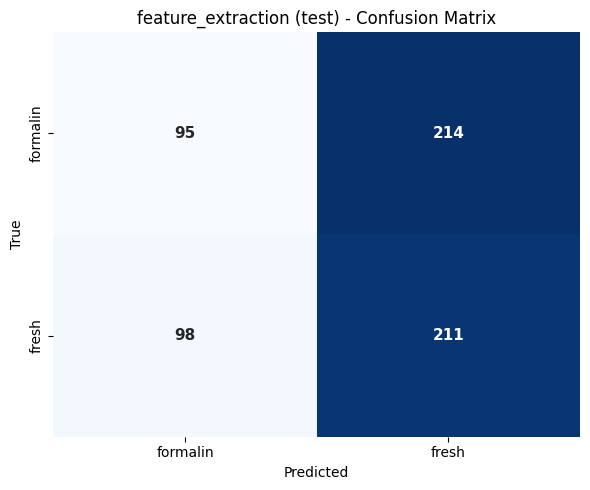

In [22]:
test_metrics = evaluate_model(final_model, test_dataset, class_names, f'{final_name} (test)')


## Predict on a single image

In [23]:
def predict_image(img_path, model, class_names, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH)):
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = np.expand_dims(tf.keras.utils.img_to_array(img), axis=0)

    plt.figure(figsize=(3, 3))
    plt.imshow(img); plt.axis('off'); plt.show()
    plt.close()

    prob = model.predict(img_array, verbose=0)[0][0]
    label = class_names[int(prob >= 0.5)]
    confidence = prob if prob >= 0.5 else 1 - prob
    print(f'{label} ({confidence:.4f})')

# predict_image('/kaggle/working/your-test-image.jpg', final_model, class_names)


## Save model

In [24]:
FINAL_MODEL_PATH = '/kaggle/working/model.keras'
final_model.save(FINAL_MODEL_PATH)
print(FINAL_MODEL_PATH, test_metrics)


/kaggle/working/model.keras {'loss': 0.7135472893714905, 'accuracy': 0.49514561891555786, 'precision': 0.4964706003665924, 'recall': 0.6828479170799255, 'f1': 0.5749318801089919, 'auc': 0.48750534653663635}
